**Nama Lengkap : Kuntur Jalassuad** <br>
**Batch JGP    : 45**

# **Final Task: Loan Prediction Model**
---
## **Prediksi Performa Kredit Peminjam**

- **Dataset:** [Loan_Data_2007-2014.csv](https://drive.google.com/file/d/1akfEs5Mfp8KZZPkzGuDiB4hR1enEK7DU/view?usp=sharing_)
- **Objective:** Membangun model Machine Learning untuk memprediksi apakah peminjam akan memiliki performa kredit yang baik (GOOD) atau buruk (BAD).
- **Algoritma:**
1. Logistic Regression,
2. Random Forest ,
3. XGBoost (Extreme Gradient Boosting),
4. Decision Tree,
5. Gradient Boosting

---

## **Import Libraries**
Mengimpor semua library yang dibutuhkan untuk manipulasi data dan komputasi data, visualisasi, preprocessing, dan pemodelan.

In [1]:
# Import library dasar untuk manipulasi data dan komputasi
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk machine learning (Clustering / PCA)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Pengaturan visualisasi
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

##**A. Data Understanding**

### Load Dataset **loan_data_2007_2014.csv**

In [2]:
# Load Data Dengan Mencantumkan dataset loan_data_2007_2014.csv yang ada pada Google Drive.
file_id = '1akfEs5Mfp8KZZPkzGuDiB4hR1enEK7DU'
file_name = 'loan_data_2007_2014.csv'
# https://drive.google.com/file/d/1akfEs5Mfp8KZZPkzGuDiB4hR1enEK7DU/view?usp=sharing
!gdown --id {file_id} --output {file_name}
df = pd.read_csv(file_name)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1akfEs5Mfp8KZZPkzGuDiB4hR1enEK7DU
From (redirected): https://drive.google.com/uc?id=1akfEs5Mfp8KZZPkzGuDiB4hR1enEK7DU&confirm=t&uuid=63b43f1b-e077-467c-8c93-3a63e73110b7
To: /content/loan_data_2007_2014.csv
100% 240M/240M [00:03<00:00, 62.4MB/s]


Informasi Dataset

In [3]:
print("===== Loan Data =====")
print(df.info())

===== Loan Data =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 

Melihat jumlah baris dan kolom

In [4]:
# Melihat jumlah baris dan kolom
print(f"Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom/fitur.")

Dataset memiliki 466285 baris dan 75 kolom/fitur.


Melihat 5 baris pertama

In [6]:
# Melihat 5 baris pertama
display(df.head())

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Eksplorasi Awal (Statistik Deskriptif & Pola Umum)**

Statistik deskriptif untuk kolom numerik

In [7]:
# Statistik deskriptif untuk kolom numerik
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


Statistik deskriptif untuk kolom kategorikal

In [9]:
# Statistik deskriptif untuk kolom kategorikal
display(df.describe(include=['O']).T)


,count,unique,top,freq
term,466285,2,36 months,337953
grade,466285,7,B,136929
sub_grade,466285,35,B3,31686
emp_title,438697,205475,Teacher,5399
emp_length,445277,11,10+ years,150049
home_ownership,466285,6,MORTGAGE,235875
verification_status,466285,3,Verified,168055
issue_d,466285,91,Oct-14,38782
loan_status,466285,9,Current,224226
pymnt_plan,466285,2,n,466276


Insight :
- Mayoritas pinjaman menggunakan tenor 36 bulan (±72%), menunjukkan preferensi peminjam terhadap pinjaman jangka menengah yang lebih cepat lunas.
- Grade kredit paling dominan adalah Grade B, khususnya Sub-grade B3, yang merepresentasikan risiko menengah.
- Sebagian besar peminjam memiliki masa kerja 10+ tahun, menandakan stabilitas pendapatan yang baik.
- Status Mortgage paling umum, menunjukkan peminjam memiliki aset namun juga kewajiban jangka panjang.
- Status Verified mendominasi, sehingga kualitas data income relatif tinggi dan dapat diandalkan untuk analisis risiko.
-  Tujuan utama pinjaman adalah Debt Consolidation, menunjukkan peminjam berusaha mengelola ulang kewajiban utangnya.
- Status Current paling banyak, menandakan portofolio pinjaman aktif masih cukup sehat.
- Peminjam terbanyak berasal dari California (CA), dengan banyak pinjaman diterbitkan sekitar 2014–2016.
- `emp_title` memiliki variasi sangat tinggi → perlu data cleaning / text normalization dan fitur `desc` banyak kosong → berpotensi bias

### **Pemeriksaan Missing Values**
Mengidentifikasi kolom-kolom yang memiliki nilai kosong (missing values).

In [8]:
# Mengecek persentase missing values tiap kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Jumlah kolom dengan missing values: {len(missing_df)} dari {df.shape[1]} kolom\n")
display(missing_df)

Jumlah kolom dengan missing values: 40 dari 75 kolom



,Missing Count,Missing %
inq_fi,466285,100.00
open_rv_24m,466285,100.00
max_bal_bc,466285,100.00
all_util,466285,100.00
inq_last_12m,466285,100.00
annual_inc_joint,466285,100.00
verification_status_joint,466285,100.00
dti_joint,466285,100.00
total_cu_tl,466285,100.00
il_util,466285,100.00


In [10]:
# Melihat nilai unik pada loan_status
print("Distribusi Loan Status:\n")
status_counts = df['loan_status'].value_counts()
for status, count in status_counts.items():
    pct = count / len(df) * 100
    print(f"  {status:55s} -> {count:>8,} ({pct:.2f}%)")

Distribusi Loan Status:

  Current                                                 ->  224,226 (48.09%)
  Fully Paid                                              ->  184,739 (39.62%)
  Charged Off                                             ->   42,475 (9.11%)
  Late (31-120 days)                                      ->    6,900 (1.48%)
  In Grace Period                                         ->    3,146 (0.67%)
  Does not meet the credit policy. Status:Fully Paid      ->    1,988 (0.43%)
  Late (16-30 days)                                       ->    1,218 (0.26%)
  Default                                                 ->      832 (0.18%)
  Does not meet the credit policy. Status:Charged Off     ->      761 (0.16%)


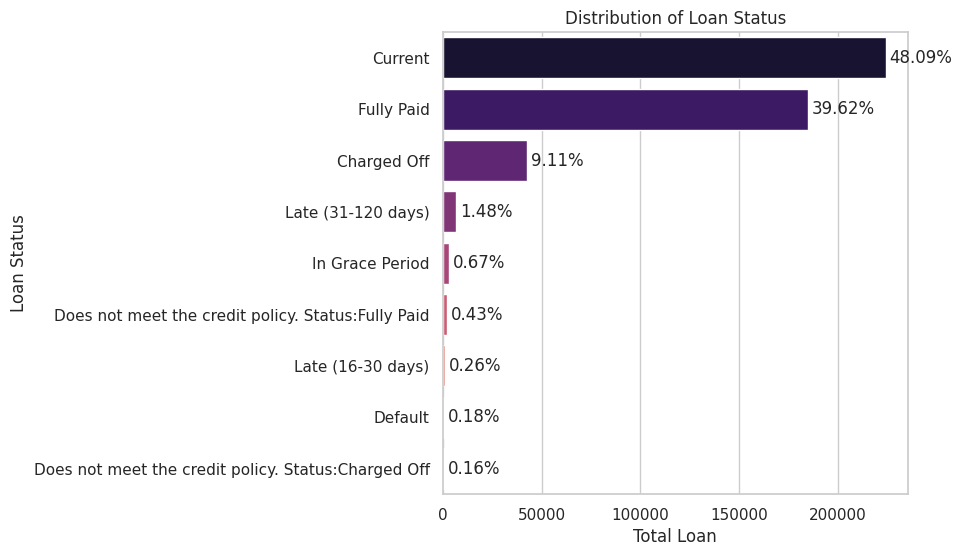

In [11]:
plt.figure(figsize=(6, 6))
sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index, palette='magma')
plt.title('Distribution of Loan Status')
plt.xlabel('Total Loan')
plt.ylabel('Loan Status')

# Menambahkan persentase pada bar
total = len(df)
for p in plt.gca().patches:
    width = p.get_width()
    plt.gca().text(width + 2000, p.get_y() + p.get_height()/2, f'{width/total*100:.2f}%', va='center')

plt.show()

### Mendefinisikan Bad Loan (1) dan Good Loan (0)

In [12]:
# Mendefinisikan Bad Loan (1) dan Good Loan (0)
good_status = ['Fully Paid', 'Current', 'Does not meet the credit policy. Status:Fully Paid']
bad_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
              'In Grace Period', 'Does not meet the credit policy. Status:Charged Off']

df['loan_label'] = df['loan_status'].apply(lambda x: 1 if x in good_status else 0)

print("Distribusi Label Target:\n")
label_counts = df['loan_label'].value_counts()
print(f"  GOOD (1): {label_counts[1]:>8,} ({label_counts[1]/len(df)*100:.2f}%)")
print(f"  BAD  (0): {label_counts[0]:>8,} ({label_counts[0]/len(df)*100:.2f}%)")

Distribusi Label Target:

  GOOD (1):  410,953 (88.13%)
  BAD  (0):   55,332 (11.87%)


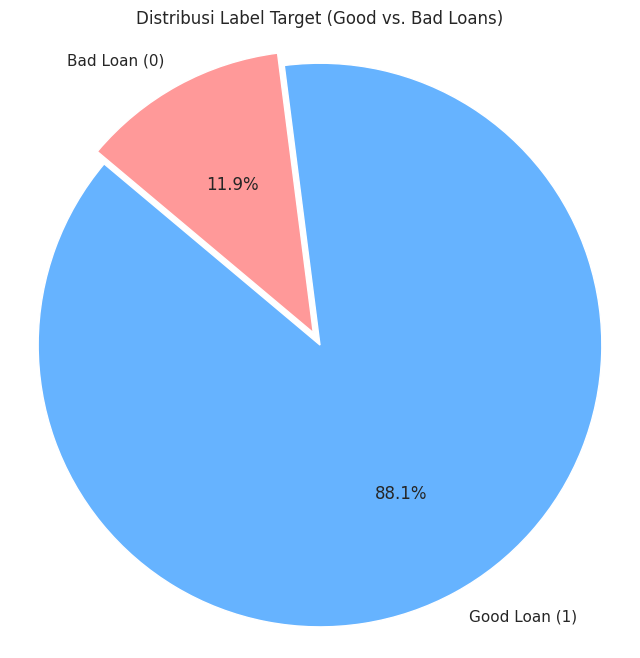

In [13]:
plt.figure(figsize=(8, 8))
labels = ['Good Loan (1)', 'Bad Loan (0)']
sizes = df['loan_label'].value_counts(normalize=True) * 100
colors = ['#66b3ff', '#ff9999'] # Contoh warna
explode = (0.05, 0)  # pisahkan sedikit irisan 'Bad Loan'

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=False, startangle=140)

plt.title('Distribusi Label Target (Good vs. Bad Loans)')
plt.axis('equal')  # Memastikan lingkaran sempurna
plt.show()

## **B. Exploratory Data Analysis (EDA)**

### **Analisis Univariat - Distribusi Variabel Numerik**

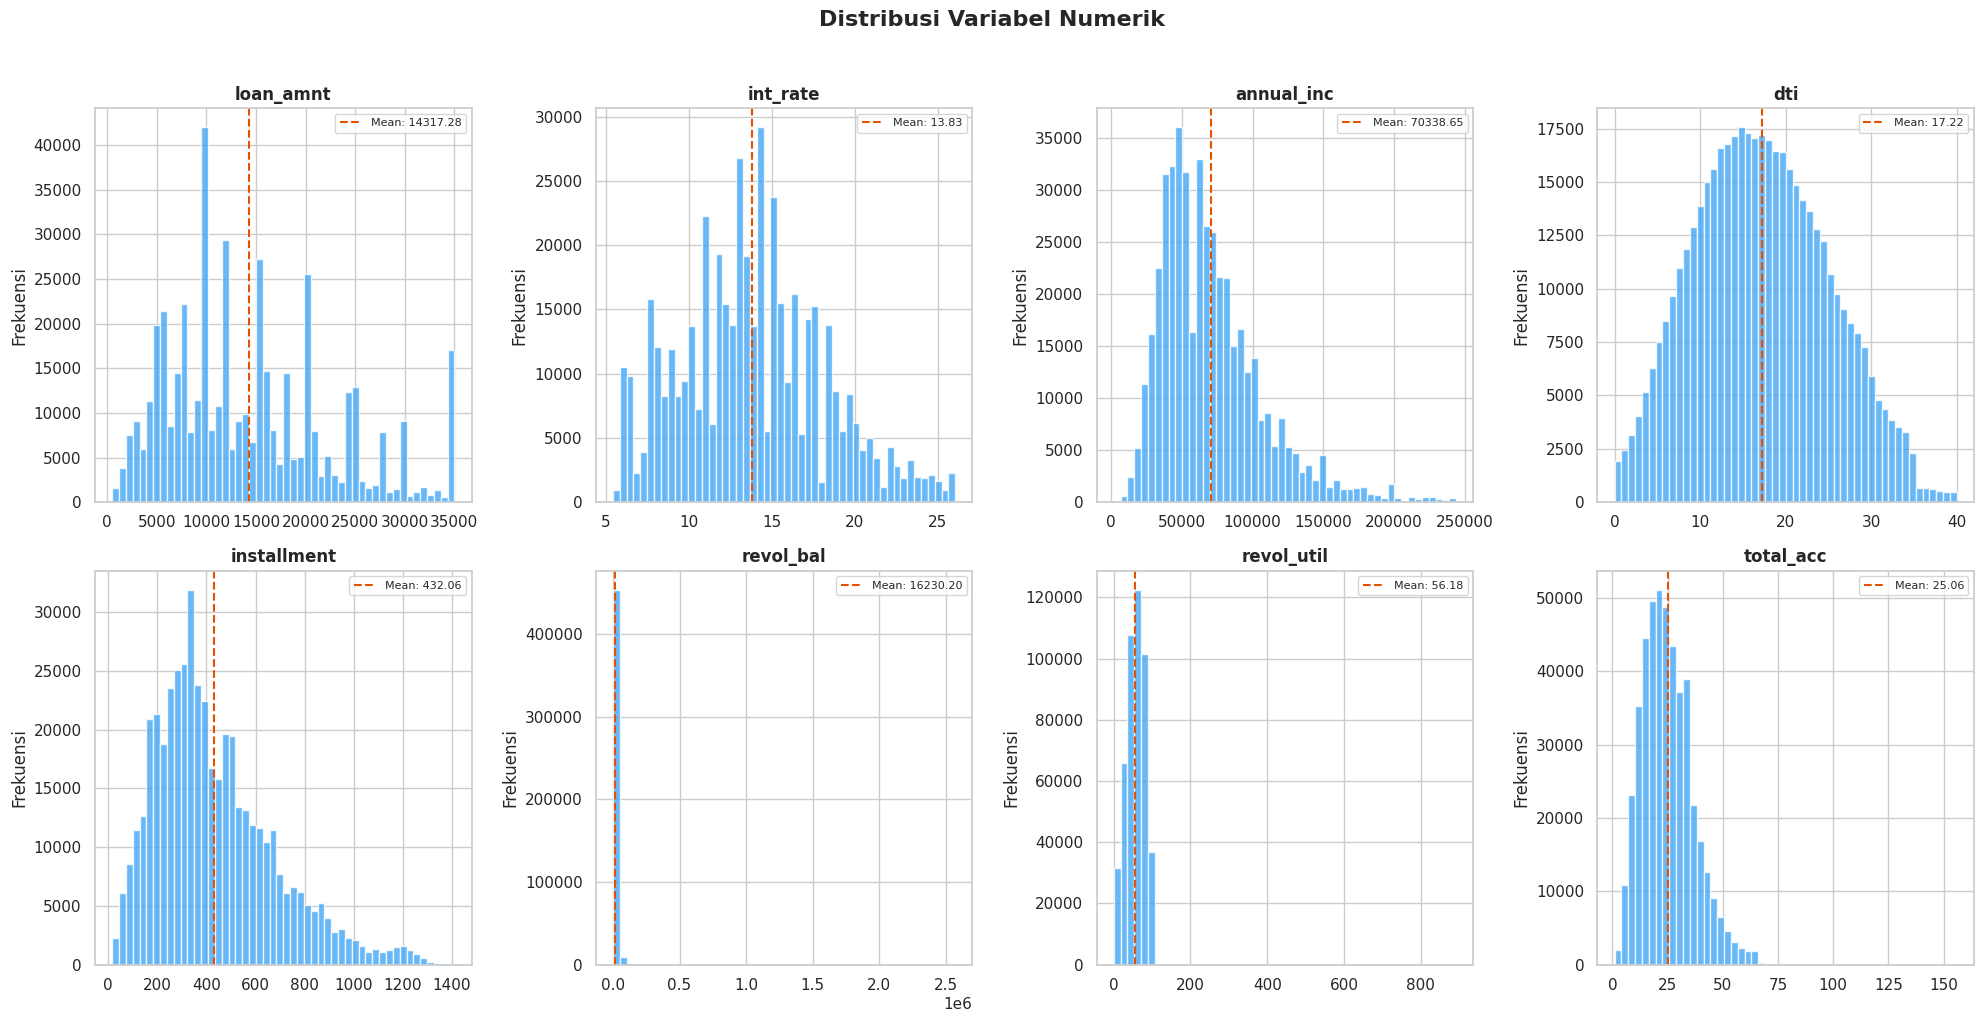

In [14]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_bal', 'revol_util', 'total_acc']
available_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(available_cols):
    data = df[col].dropna()
    if col == 'annual_inc':
        data = data[data < data.quantile(0.99)]
    axes[i].hist(data, bins=50, color='#42A5F5', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(data.mean(), color='#E65100', linestyle='--', label=f'Mean: {data.mean():.2f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribusi Variabel Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**INSIGHT** :
- Loan Amount `loan_amnt` : Distribusi pinjaman cenderung right-skewed, dengan mayoritas pinjaman berada di nilai menengah dan hanya sebagian kecil pinjaman bernilai sangat besar. Pinjaman bernilai besar berpotensi meningkatkan risiko default absolut, meskipun jumlah kasusnya lebih sedikit.\
-  Interest Rate `int_rate` : Suku bunga terkonsentrasi di kisaran 10–15%, dengan distribusi mendekati normal namun sedikit condong ke kanan. Interest rate mencerminkan grading risiko internal, sehingga sangat relevan sebagai prediktor terhadap loan_status.
- Annual Income `annual_inc` : Distribusi pendapatan tahunan sangat right-skewed, mayoritas peminjam berpenghasilan menengah dengan outlier berpenghasilan sangat tinggi. Disarankan menggunakan log transformation untuk modeling.
- Debt-to-Income Ratio `dti` : Distribusi DTI berbentuk mendekati normal, dengan konsentrasi di kisaran 10–20%. DTI adalah indikator utama kemampuan bayar borrower. Nilai DTI ekstrem (tinggi) berpotensi mengindikasikan risiko default lebih besar.
- Installment `installment` : Distribusi cicilan bulanan right-skewed, mengikuti pola loan_amnt dan term. Installment berhubungan langsung dengan cash flow pressure peminjam. Cocok digunakan bersama annual_inc → installment-to-income ratio.
- Revolving Balance `revol_bal` : Distribusi sangat heavy-tailed, sebagian besar peminjam memiliki saldo kecil, sementara sedikit borrower menanggung saldo revolving sangat besar. Outlier perlu penanganan (winsorization / log).
Nilai tinggi dapat mengindikasikan over-leverage.
- Revolving Utilization `revol_util` : Mayoritas peminjam berada di bawah 50% utilization, namun terdapat ekor kanan hingga mendekati 100%. Revolving utilization adalah early warning variable untuk potensi delinquency.
- Total Accounts `total_acc` : Distribusi unimodal, mayoritas peminjam memiliki 10–40 akun kredit. Jumlah akun mencerminkan credit experience.

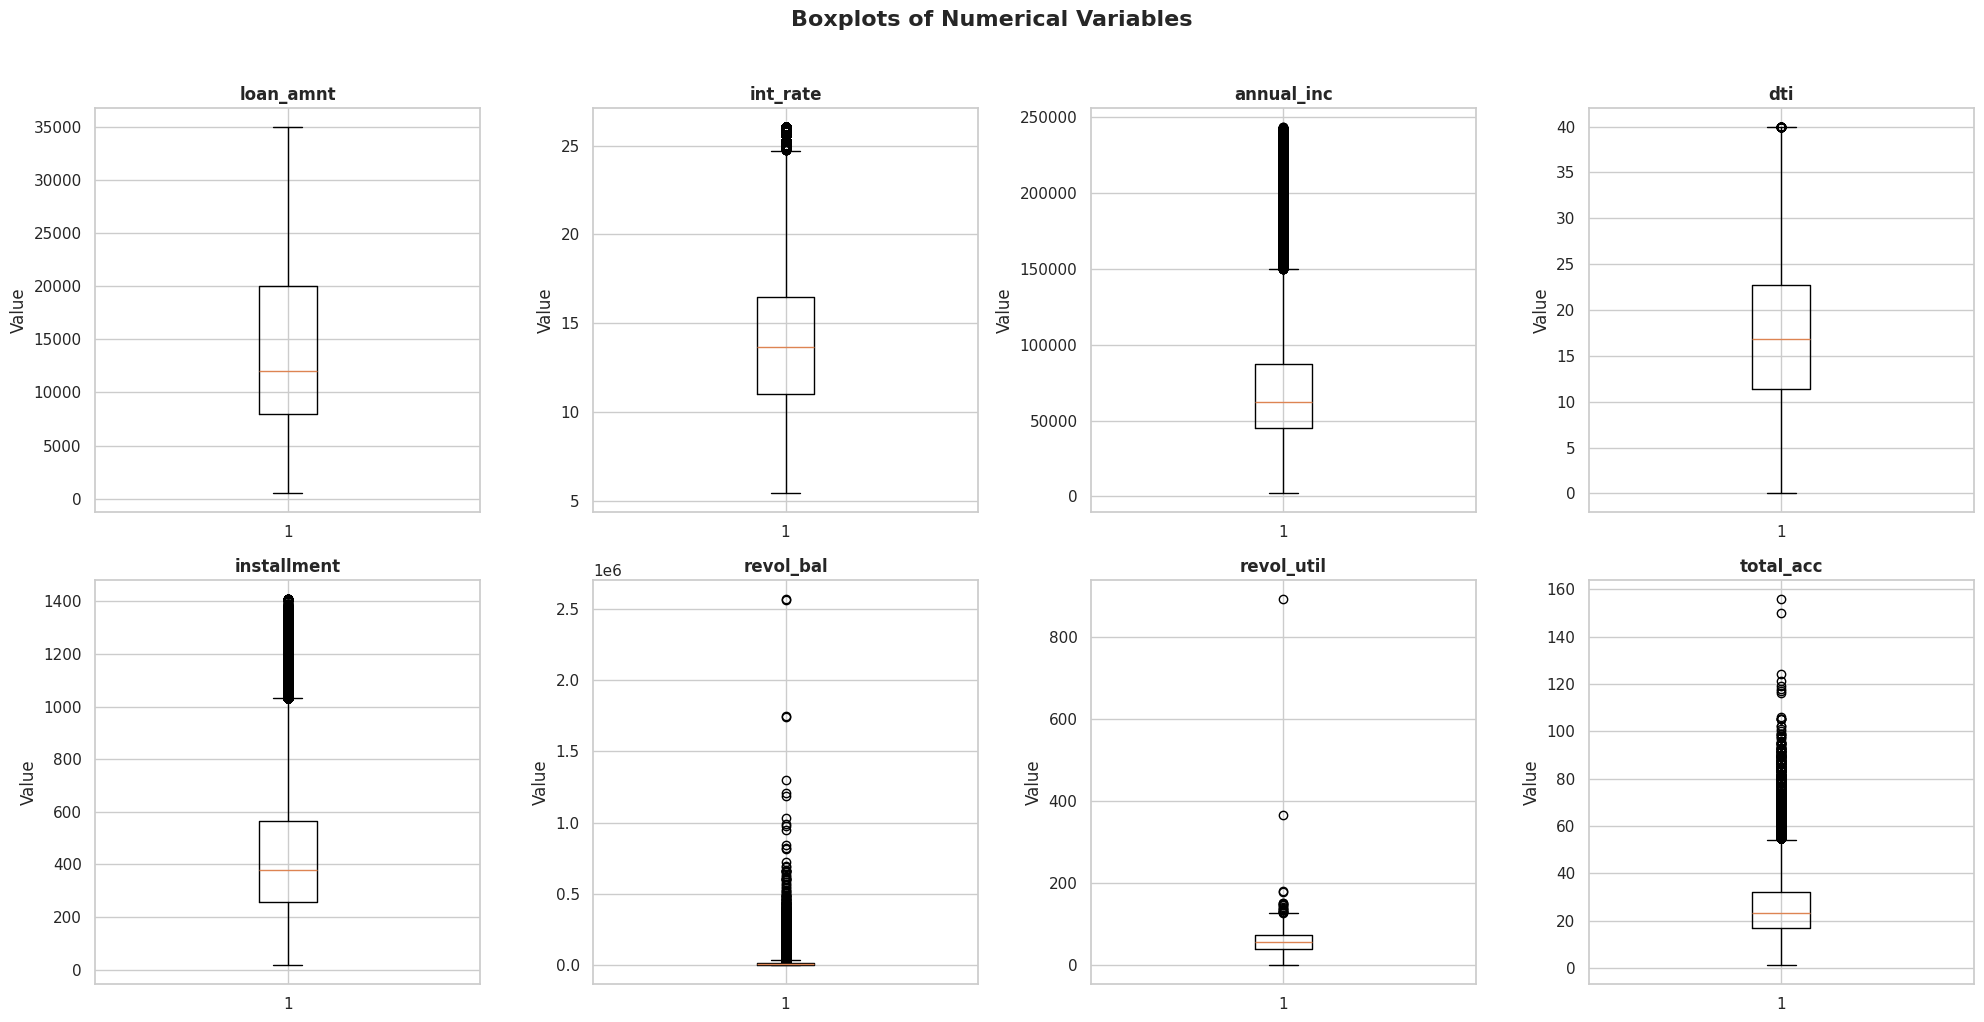

In [17]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_bal', 'revol_util', 'total_acc']
available_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(available_cols):
    data = df[col].dropna()
    if col == 'annual_inc':
        data = data[data < data.quantile(0.99)]
    axes[i].boxplot(data)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value') # Updated ylabel for boxplot
plt.suptitle('Boxplots of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**INSIGHT** :
- Hampir semua variabel numerik memiliki outlier signifikan
- Loan Amount (loan_amnt) : Boxplot menunjukkan sebaran yang lebar dengan median di kisaran menengah dan banyak outlier bernilai tinggi.
- Interest Rate (int_rate) : Suku bunga relatif terkonsentrasi, dengan beberapa outlier di tingkat bunga tinggi.
- Annual Income (annual_inc) : Distribusi sangat right-skewed, dengan banyak outlier ekstrem jauh di atas Q3.
- Debt-to-Income Ratio (dti) : DTI memiliki sebaran moderat, namun terdapat outlier dengan rasio sangat tinggi.
- Installment (installment) : Nilai cicilan menunjukkan right-skewness, dengan beberapa cicilan sangat besar dibanding mayoritas.
- Revolving Balance (revol_bal) : Boxplot menunjukkan banyak outlier ekstrem, menandakan ketimpangan saldo kredit revolving.
- Revolving Utilization (revol_util) : Sebagian besar peminjam memiliki utilization rendah–menengah, namun terdapat outlier mendekati 100%+.
- Total Accounts (total_acc) : Jumlah akun kredit relatif terkonsentrasi, dengan outlier mencerminkan borrower berpengalaman kredit tinggi.

Terlihat Outlier pada fitur `annual_inc`, `dti`, `revol_bal`, `revol_util` yang perlu penanganan Outlier

### **Analisis Bivariat - Distribusi Variabel Numerik dengan Status Pinjaman**

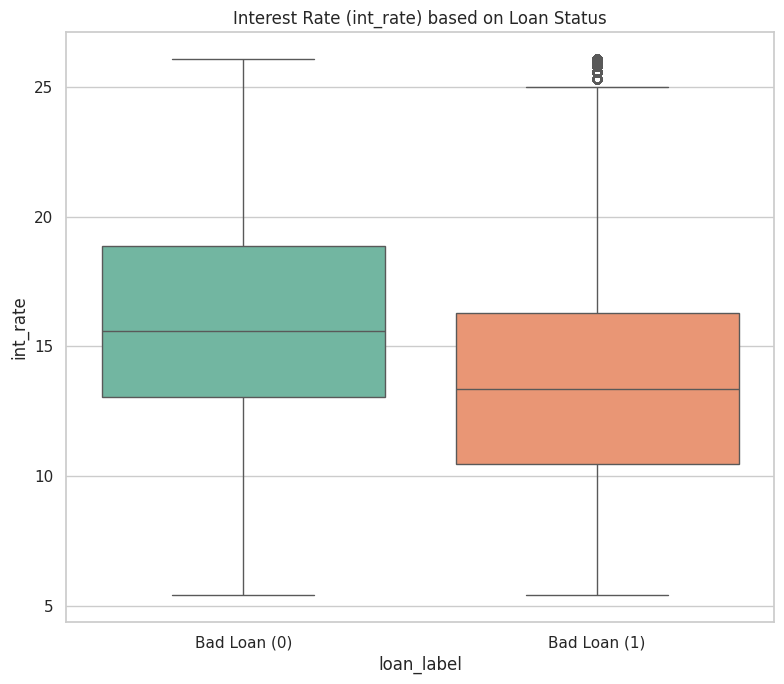

In [24]:
# Analisis Bivariat: Suku Bunga vs Status Pinjaman
plt.figure(figsize=(8, 7))
sns.boxplot(x='loan_label', y='int_rate', data=df, palette='Set2')
plt.title('Interest Rate (int_rate) based on Loan Status')
plt.xticks([0, 1], ['Bad Loan (0)', 'Bad Loan (1)'])
plt.tight_layout()
plt.show()

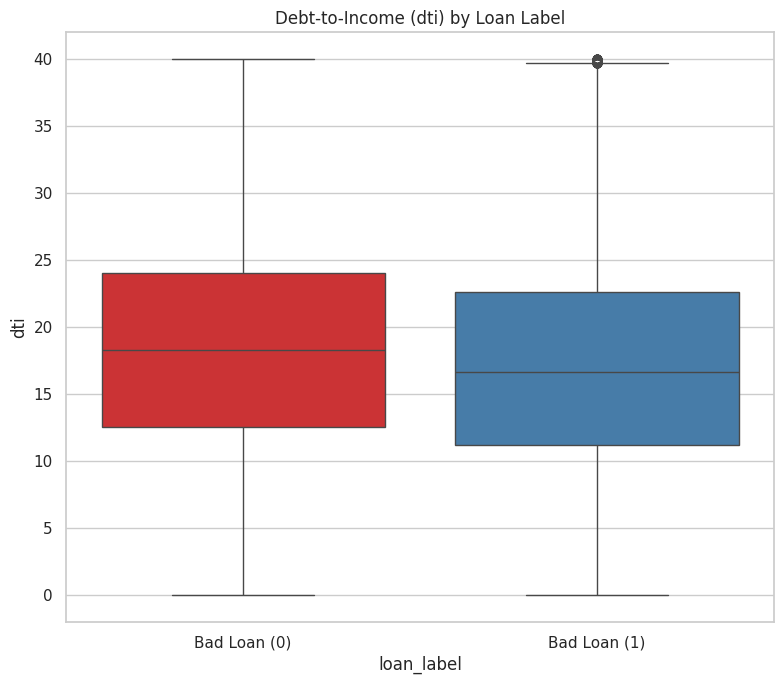

In [25]:
# Analisis Bivariat: Debt to Income (DTI) vs Status
plt.figure(figsize=(8, 7))
sns.boxplot(x='loan_label', y='dti', data=df[df['dti'] < 50], palette='Set1') # Filter outlier ekstrim di DTI
plt.title('Debt-to-Income (dti) by Loan Label')
plt.xticks([0, 1], ['Bad Loan (0)', 'Bad Loan (1)'])

plt.tight_layout()
plt.show()

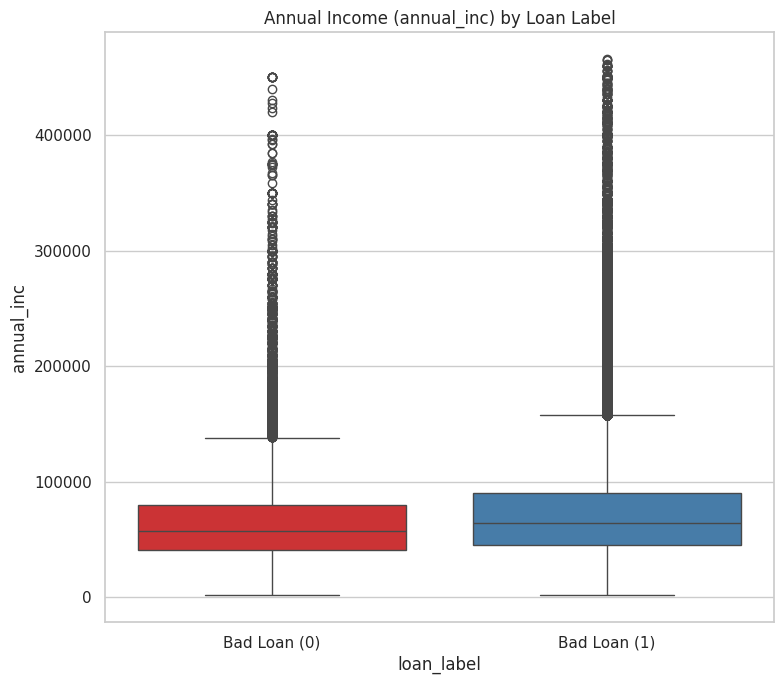

In [26]:
# Analisis Bivariat: Annual Income vs Status
plt.figure(figsize=(8, 7))
data_annual_inc = df['annual_inc'].dropna()
data_annual_inc = data_annual_inc[data_annual_inc < data_annual_inc.quantile(0.99)]
sns.boxplot(x='loan_label', y='annual_inc', data=df[df['annual_inc'].isin(data_annual_inc.index)], palette='Set1')
plt.title('Annual Income (annual_inc) by Loan Label')
plt.xticks([0, 1], ['Bad Loan (0)', 'Bad Loan (1)'])

plt.tight_layout()
plt.show()

Insight :

terlihat bahwa median `annual_inc` untuk peminjam 'Good Loan' sedikit lebih tinggi dibandingkan dengan 'Bad Loan'. Selain itu, sebaran data (IQR) untuk 'Good Loan' juga tampak lebih luas ke arah pendapatan yang lebih tinggi, mengindikasikan bahwa peminjam dengan pendapatan yang lebih baik cenderung memiliki performa kredit yang lebih baik.

### **Analisis Variabel Kategorikal**

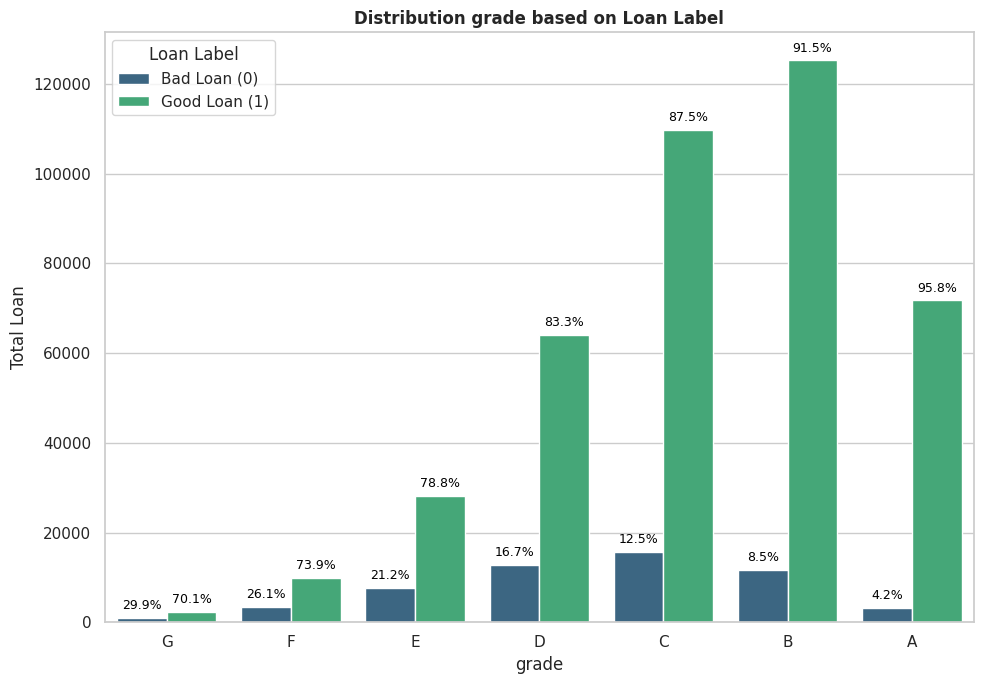

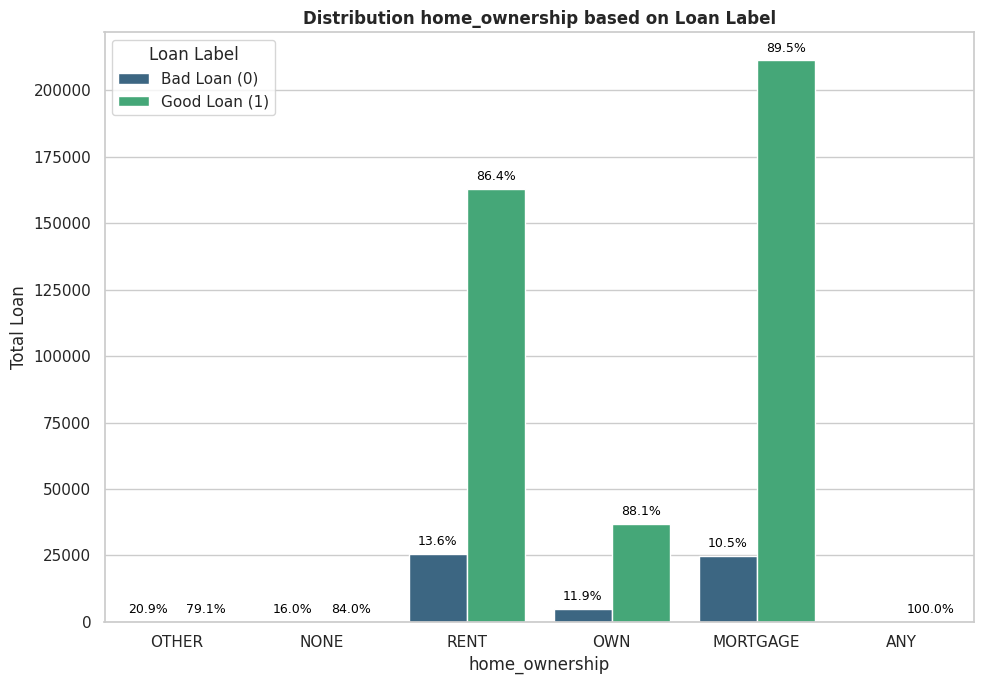

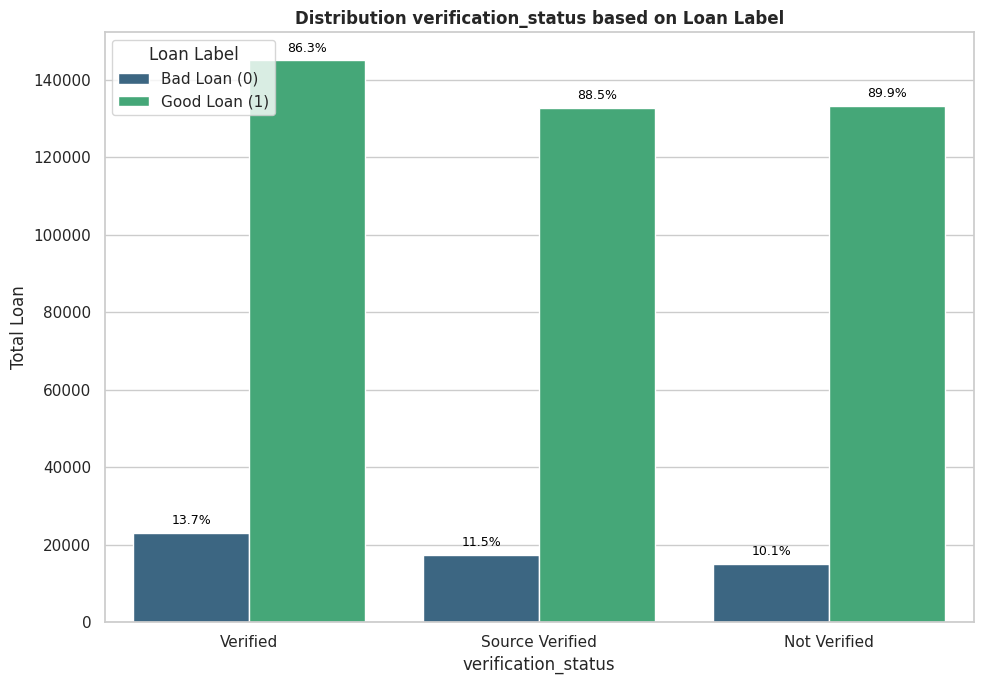

In [28]:
cat_cols = ['grade', 'home_ownership', 'verification_status']

for col in cat_cols:
    plt.figure(figsize=(10, 7))

    # Calculate bad loan percentage for sorting
    bad_loan_counts = df[df['loan_label'] == 0][col].value_counts()
    total_counts = df[col].value_counts()
    bad_loan_percentage = (bad_loan_counts / total_counts * 100).fillna(0)

    # Get the order of categories sorted by bad loan percentage in descending order
    ordered_categories = bad_loan_percentage.sort_values(ascending=False).index

    # Membuat vertikal bar chart: 'x' sekarang adalah kolom kategori, 'y' adalah hitungan
    # Mengurutkan bar berdasarkan persentase bad loan tertinggi
    ax = sns.countplot(x=col, hue='loan_label', data=df, palette='viridis', order=ordered_categories)

    plt.title(f'Distribution {col} based on Loan Label', fontweight='bold')
    plt.xlabel(col) # X-axis mewakili variabel kategorikal
    plt.ylabel('Total Loan') # Y-axis mewakili hitungan (count)

    # Iterasi melalui setiap container bar (satu untuk setiap level hue, misal loan_label 0 dan 1)
    for container_idx, container in enumerate(ax.containers):
        # Iterasi melalui setiap bar di dalam container saat ini
        for bar_idx, bar in enumerate(container):
            height = bar.get_height() # Tinggi bar vertikal adalah nilai (jumlah)
            if height > 0: # Hanya beri anotasi pada bar yang memiliki nilai
                # Ambil nama kategori yang terkait dengan bar ini (dari label tick x-axis)
                category_name = ordered_categories[bar_idx] # Use ordered_categories for correct indexing

                # Hitung persentase dari hitungan bar ini relatif terhadap total hitungan untuk kategorinya
                percentage = (height / total_counts[category_name]) * 100

                # Tambahkan label persentase di atas bar
                # Posisi x: tengah bar secara horizontal
                # Posisi y: tinggi bar + sedikit offset (misal, 1% dari nilai y-axis maksimum)
                ax.text(bar.get_x() + bar.get_width() / 2,
                        height + (ax.get_ylim()[1] * 0.01),
                        f'{percentage:.1f}%',
                        ha='center', va='bottom', color='black', fontsize=9)

    # Sesuaikan label legenda agar lebih jelas
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['Bad Loan (0)', 'Good Loan (1)'], title='Loan Label')

    plt.tight_layout()
    plt.show()

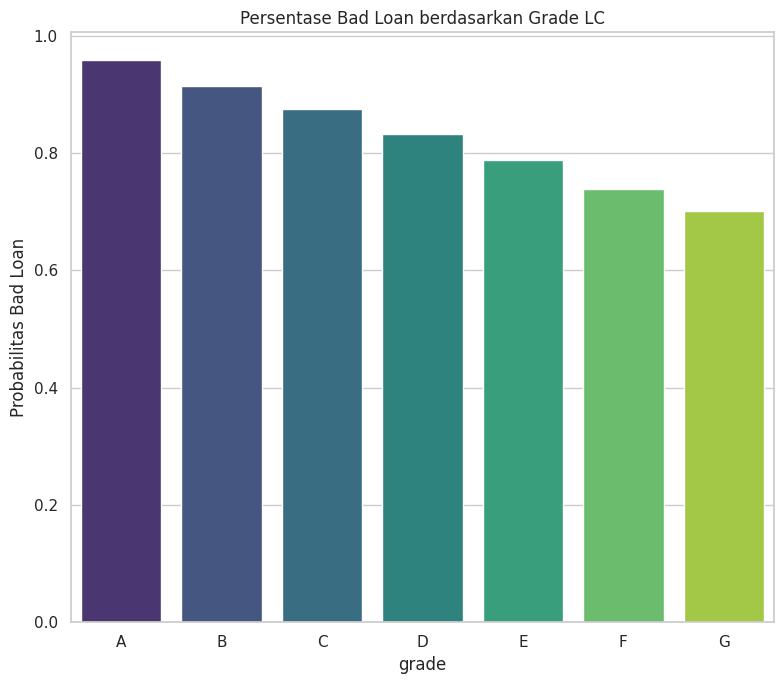

In [30]:
# Analisis Bivariat: Grade Pinjaman vs Persentase Bad Loan
plt.figure(figsize=(8, 7))
grade_order = sorted(df['grade'].dropna().unique())
sns.barplot(x='grade', y='loan_label', data=df, order=grade_order, palette='viridis', ci=None)
plt.title('Persentase Bad Loan berdasarkan Grade LC')
plt.ylabel('Probabilitas Bad Loan')
plt.tight_layout()
plt.show()

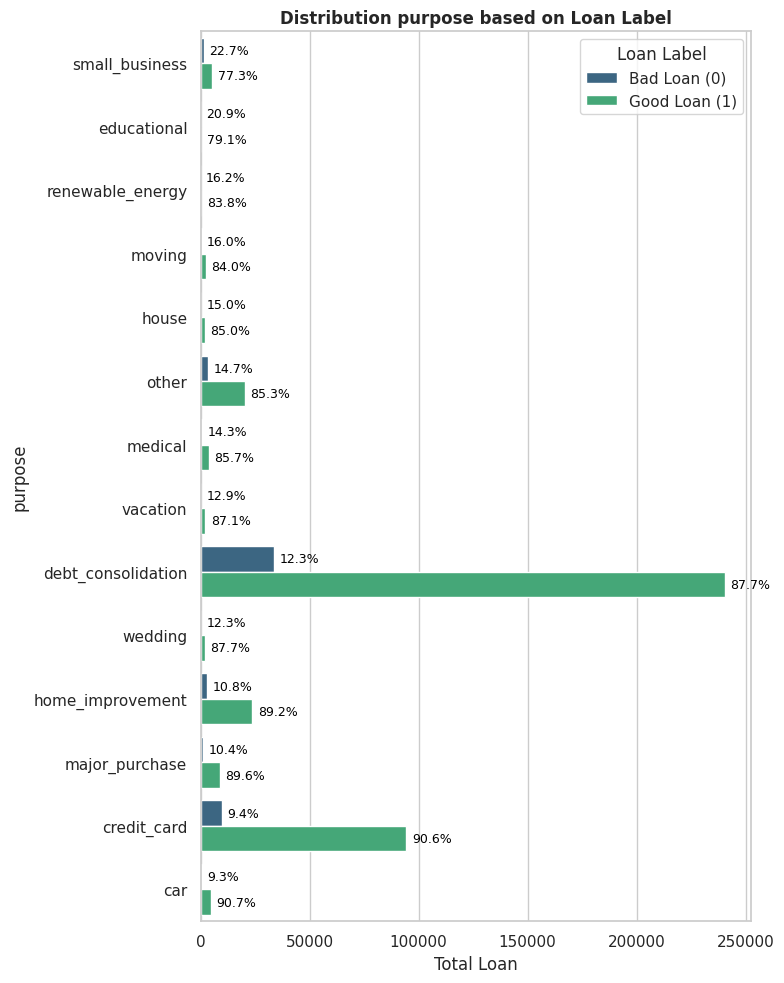

In [29]:
cat_cols = ['purpose']

for col in cat_cols:
    plt.figure(figsize=(8, 10))

    # Calculate bad loan percentage for sorting
    bad_loan_counts = df[df['loan_label'] == 0][col].value_counts()
    total_counts = df[col].value_counts()
    bad_loan_percentage = (bad_loan_counts / total_counts * 100).fillna(0)

    # Get the order of categories sorted by bad loan percentage in descending order
    ordered_categories = bad_loan_percentage.sort_values(ascending=False).index

    # Mengurutkan bar berdasarkan persentase bad loan tertinggi
    ax = sns.countplot(y=col, hue='loan_label', data=df, palette='viridis', order=ordered_categories)

    plt.title(f'Distribution {col} based on Loan Label', fontweight='bold')
    plt.ylabel(col) # Y-axis mewakili variabel kategorikal
    plt.xlabel('Total Loan') # X-axis mewakili hitungan (count)

    # Menghitung total hitungan untuk setiap kategori pada y-axis
    # Menggunakan total_counts yang sudah dihitung untuk persentase

    # Iterasi melalui setiap container bar (satu untuk setiap level hue, misal loan_label 0 dan 1)
    for container_idx, container in enumerate(ax.containers):
        # Iterasi melalui setiap bar di dalam container saat ini
        for bar_idx, bar in enumerate(container):
            width = bar.get_width() # Lebar bar horizontal adalah nilai (jumlah)
            if width > 0: # Hanya beri anotasi pada bar yang memiliki nilai
                # Ambil nama kategori yang terkait dengan bar ini (dari label tick y-axis)
                category_name = ordered_categories[bar_idx] # Use ordered_categories for correct indexing

                # Hitung persentase dari hitungan bar ini relatif terhadap total hitungan untuk kategorinya
                percentage = (width / total_counts[category_name]) * 100

                # Tambahkan label persentase di samping bar
                ax.text(width + (ax.get_xlim()[1] * 0.01),
                        bar.get_y() + bar.get_height() / 2,
                        f'{percentage:.1f}%',
                        ha='left', va='center', color='black', fontsize=9)

    # Sesuaikan label legenda agar lebih jelas
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['Bad Loan (0)', 'Good Loan (1)'], title='Loan Label')

    plt.tight_layout()
    plt.show()

Menganalisis Korelasi antar Fitur

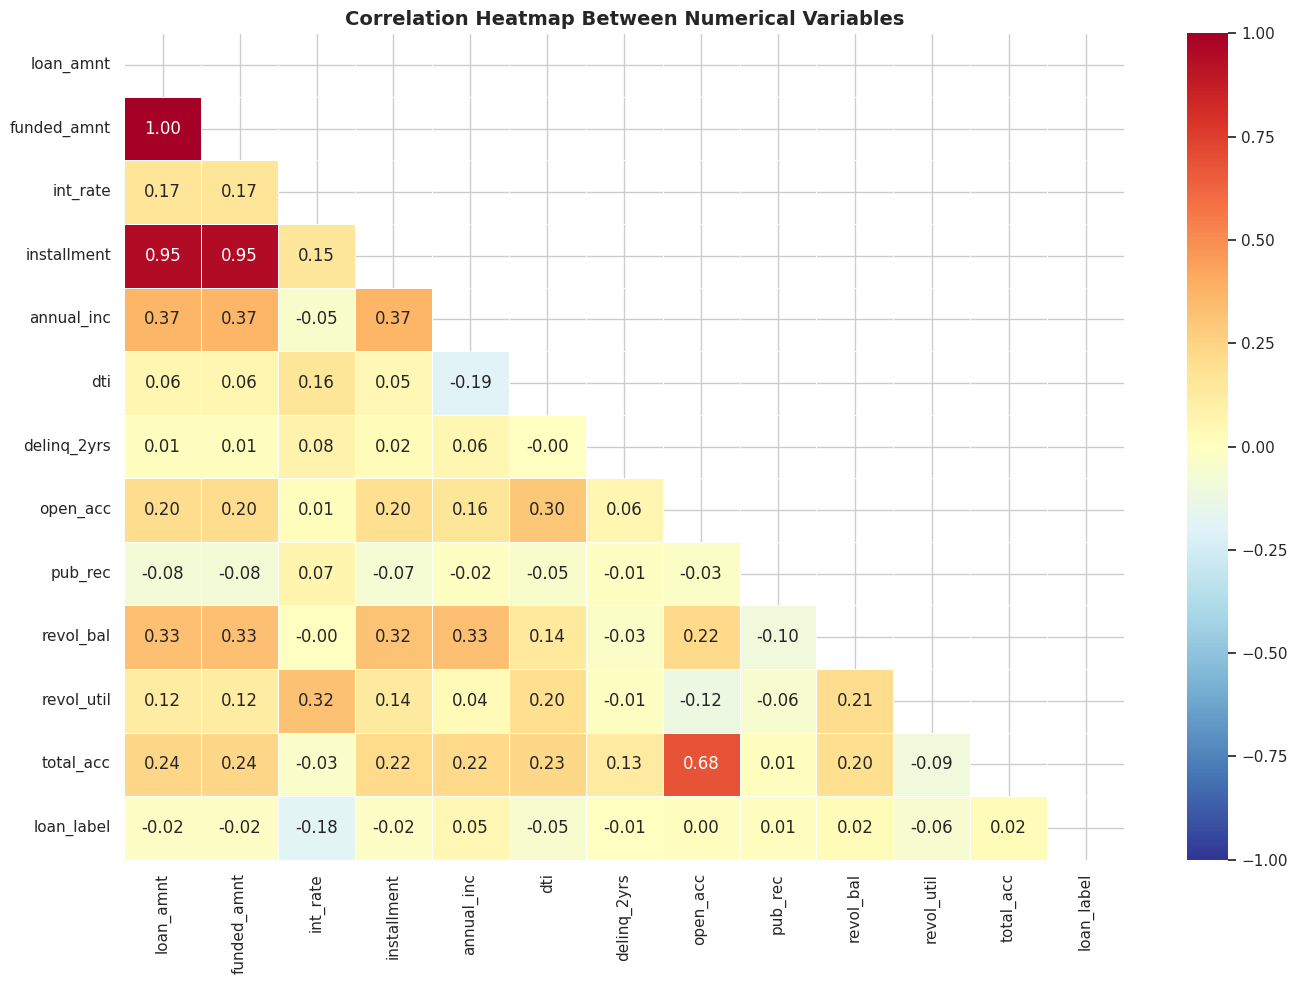

In [32]:
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal',
             'revol_util', 'total_acc', 'loan_label']
available_corr = [c for c in corr_cols if c in df.columns]

corr_matrix = df[available_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap Between Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Analisis Faktor / Clustering**

In [46]:
# Mengambil sampel data agar komputasi tidak terlalu berat saat eksplorasi (misal 50.000 baris)
num_features = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'total_acc', 'loan_label']
df_sample = df[num_features].dropna().sample(50000, random_state=42)

In [47]:
# Pisahkan fitur dari target untuk clustering
X_cluster = df_sample.drop('loan_label', axis=1)

# Standardisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [48]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) # Menghitung WCSS / Inertia

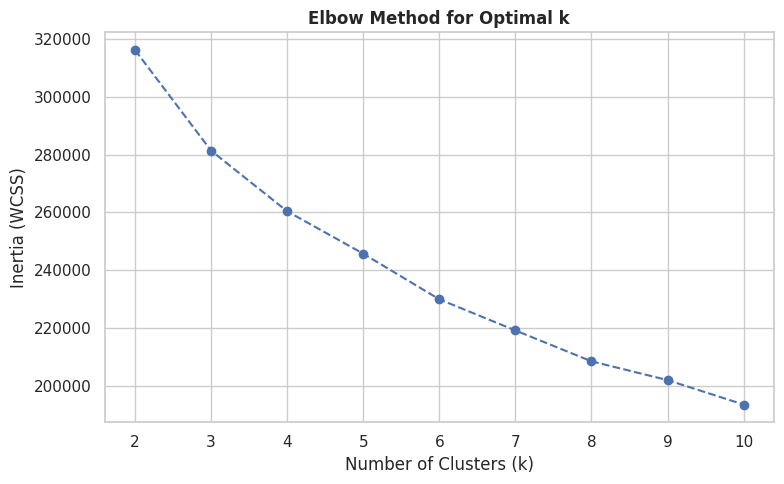

In [49]:
# Membuat Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k', fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_method.png')

In [50]:
# Reduksi Dimensi dengan PCA (menjadi 2 dimensi agar mudah divisualisasikan)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Menerapkan K-Means Clustering (Misal kita asumsikan ada 3 segmen peminjam)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

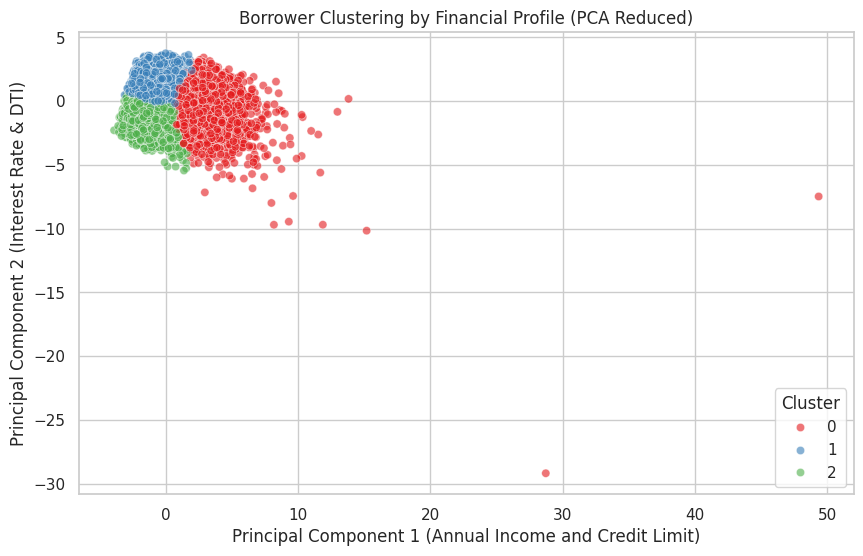

In [54]:
# Plot Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set1', alpha=0.6)
plt.title('Borrower Clustering by Financial Profile (PCA Reduced)')
plt.xlabel('Principal Component 1 (Annual Income and Credit Limit)')
plt.ylabel('Principal Component 2 (Interest Rate & DTI)')
plt.legend(title='Cluster', loc='lower right')
plt.show()

In [55]:
# Melihat rata-rata nilai per cluster untuk mendapatkan insight bisnis
df_sample['Cluster'] = clusters
display(df_sample.groupby('Cluster').mean())

,loan_amnt,int_rate,installment,annual_inc,dti,revol_bal,revol_util,total_acc,loan_label
Cluster,,,,,,,,,
0,25438.806506,14.762893,752.895169,110916.683761,17.767322,29506.219724,61.810006,30.901937,0.879375
1,10899.998760,15.608661,336.456439,56278.665941,20.451991,13723.483879,69.635089,22.366022,0.848363
2,10129.982078,11.123133,308.708482,65611.238638,13.026493,9287.498757,36.231814,24.033532,0.920564


**Insight Bisnis per Cluster** <br>
-  **Cluster 0 — High Income, High Leverage Borrower**  <br>
Ciri utama : <br>
1. loan_amnt tertinggi ≈ 25.4k
2. annual_inc tertinggi ≈ 110k
3. installment besar → beban cicilan berat
4. revol_util 61.8% (cukup tinggi)
5. total_acc 30.9 (sangat banyak akun kredit)
6. loan_label 0.879 (baik, tapi bukan terbaik)  <br> ***Makna bisnis*** :
Ini peminjam mapan secara income, tetapi Sangat aktif berutang dan memiliki Leverage tinggi
 <br>


- **Cluster 1 — Stressed Borrower dengan Utilization Tinggi** <br>
Ciri utama : <br>
1. annual_inc terendah ≈ 56k
2. dti tertinggi ≈ 20.45
3. revol_util tertinggi ≈ 69.6%
4. int_rate tertinggi (15.6%)
5. loan_label 0.848 (paling rendah) <br> ***Makna bisnis:***
Segmen Ini peminjam yang Sudah menggunakan hampir seluruh limit kredit
Punya ruang napas finansial paling sempit.Walaupun pinjamannya tidak besar, risiko gagal bayar paling nyata

<br>

- **Cluster 2 — Low Risk, Financially Disciplined Borrowerr**  <br>
Ciri utama : <br>
1. loan_amnt paling kecil ≈ 10.1k
2. int_rate terendah ≈ 11.1%
3. dti terendah ≈ 13.0
4. revol_util sangat rendah ≈ 36.2%
5. loan_label tertinggi ≈ 0.921  <br> ***Interpretasi PCA*** :
Berada di kiri atas → pendapatan kecil, risiko jelas tinggi, dan Suku bunga tinggi tidak cukup untuk menutup risiko.  <br>
***Makna bisnis :*** Segmen Ini peminjam Tidak agresif berutang
Mengelola kredit dengan sangat baik. Income bukan paling tinggi, tapi Kualitas kredit paling kuat.

### Feature Engineering

Menambahkan Feature Engineering untuk Sejarah Keterlambatan Pembayaran

In [56]:
# 1. Flag Keterlambatan Historis (Biner)

# Membuat flag: Apakah nasabah PERNAH telat bayar dalam 2 tahun terakhir? (1=Ya, 0=Tidak)
if 'delinq_2yrs' in df.columns:
    df['has_history_delinq'] = np.where(df['delinq_2yrs'] > 0, 1, 0)

In [57]:
# 2. Derogatory Public Records (Catatan Hitam / Kebangkrutan)
# Ini adalah level keterlambatan paling parah. Kita buat flag biner.
if 'pub_rec' in df.columns:
    df['has_public_record'] = np.where(df['pub_rec'] > 0, 1, 0)

In [58]:
# 3. Currently Delinquent (Status Menunggak Saat Pengajuan)
# Sangat berisiko jika nasabah sedang menunggak di tempat lain saat minta pinjaman baru.
if 'acc_now_delinq' in df.columns:
    df['is_currently_delinq'] = np.where(df['acc_now_delinq'] > 0, 1, 0)

In [59]:
# Cek hasil fitur baru
display(df[['delinq_2yrs', 'has_history_delinq','has_public_record', 'is_currently_delinq']].sample(5))

,delinq_2yrs,has_history_delinq,has_public_record,is_currently_delinq
240970,0.0,0,0,0
406654,0.0,0,0,0
425488,1.0,1,0,0
310597,0.0,0,0,0
55051,0.0,0,1,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

## **C. Data Preparation**

### Seleksi Fitur
Memilih fitur-fitur yang relevan untuk pemodelan dan menghapus kolom yang tidak diperlukan.

**Kolom yang dihapus:**
- Kolom identitas: `id`, `member_id`, `url`, `desc`, `title`, `emp_title`, `zip_code`
- Kolom status yang sudah digunakan sebagai label: `loan_label`
- Kolom post-loan (data yang hanya tersedia setelah pinjaman diberikan): `out_prncp`, `total_pymnt`, `recoveries`, dll.
- Kolom joint application (terlalu banyak missing): `annual_inc_joint`, `dti_joint`, dll.
- Kolom dengan data sangat sparse: `open_acc_6m`, `open_il_6m`, dll.

In [62]:
drop_cols = ['Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title', 'emp_title',
             'zip_code', 'pymnt_plan', 'policy_code', 'application_type',
             'annual_inc_joint', 'dti_joint', 'verification_status_joint',
             'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
             'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
             'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
             'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
             'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
             'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
             'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d']

existing_drop = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=existing_drop)
print(f"Features before selection: {df.shape[1]}")
print(f"Features after selection: {df_clean.shape[1]}")
print(f"\nFeatures used:\n{list(df_clean.columns)}")

Features before selection: 79
Features after selection: 38

Features used:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'loan_label', 'has_history_delinq', 'has_public_record', 'is_currently_delinq']


In [64]:
# Menentukan threshold (misal: hapus kolom jika missing value > 30%)
threshold = 0.3
df_clean = df_clean.loc[:, df_clean.isnull().mean() < threshold] # Changed df to df_clean
print(f"Features before selection: {df.shape[1]}")
print(f"Features after selection: {df_clean.shape[1]}")
print(f"\nFeatures used:\n{list(df_clean.columns)}")

df_clean.info() # Changed df to df_clean

Features before selection: 79
Features after selection: 35

Features used:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'loan_label', 'has_history_delinq', 'has_public_record', 'is_currently_delinq']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv            

In [68]:
# Memisahkan kolom numerik dan kategorikal yang tersisa
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

### Menangani Nilai yang Hilang (Missing Values)

In [69]:
# Imputasi nilai yang hilang
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna(df_clean[cat_cols].mode().iloc[0])

print("Missing values ​​after imputation:\n", df_clean.isnull().sum().max())

Missing values ​​after imputation:
 0


### Mengatasi Outlier (Pencilan Data)

In [70]:
outlier_cols = ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'delinq_2yrs']
available_outlier = [c for c in outlier_cols if c in df_clean.columns]

print("Handling Outlier (IQR capping):\n")
for col in available_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {outliers_before:,} outlier di-cap (range: {lower:.2f} - {upper:.2f})")

print(f"\nOutlier handling completed. Shape: {df_clean.shape}")

Handling Outlier (IQR capping):

  annual_inc: 19,899 outlier di-cap (range: -20929.50 - 154882.50)
  dti: 43 outlier di-cap (range: -5.77 - 39.91)
  revol_bal: 22,879 outlier di-cap (range: -14467.00 - 41213.00)
  revol_util: 19 outlier di-cap (range: -14.05 - 127.95)
  delinq_2yrs: 83,302 outlier di-cap (range: 0.00 - 0.00)

Outlier handling completed. Shape: (466285, 35)


### Encoding pada Variabel Kategorikal

In [ ]:
cat_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
num_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'loan_label' in num_columns:
    num_columns.remove('loan_label')

print(f"Categorical Features ({len(cat_columns)}): {cat_columns}")
print(f"Numerical Features: {len(num_columns)} Features")

In [73]:
le_dict = {}
for col in cat_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le
    print(f"  {col}: {len(le.classes_)} encoded categories")

print(f"\nShape data after encoding: {df_clean.shape}")

  term: 2 encoded categories
  grade: 7 encoded categories
  sub_grade: 35 encoded categories
  emp_length: 11 encoded categories
  home_ownership: 6 encoded categories
  verification_status: 3 encoded categories
  issue_d: 91 encoded categories
  loan_status: 9 encoded categories
  purpose: 14 encoded categories
  addr_state: 50 encoded categories
  earliest_cr_line: 664 encoded categories
  initial_list_status: 2 encoded categories

Shape data after encoding: (466285, 35)


In [75]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  int64  
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  int64  
 7   sub_grade                   466285 non-null  int64  
 8   emp_length                  466285 non-null  int64  
 9   home_ownership              466285 non-null  int64  
 10  annual_inc                  466285 non-null  float64
 11  verification_status         466285 non-null  int64  
 12  issue_d                     466285 non-null  int64  
 13  loan_status   

### Membagi Data (Train-Test Split)

In [76]:
from sklearn.model_selection import train_test_split

# Menyiapkan fitur (X) dan target (y)
# Kita drop target 'loan_label' dan target original 'loan_status' jika masih ada
cols_to_drop_from_X = ['loan_label', 'loan_status']
X = df_clean.drop(columns=[col for col in cols_to_drop_from_X if col in df_clean.columns])
y = df_clean['loan_label']

# Split Data (80:20) dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

Dimensi X_train: (373028, 33)
Dimensi X_test: (93257, 33)


In [77]:
X.sample(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,has_history_delinq,has_public_record,is_currently_delinq
179263,33425,33425,33375.0,1,19.05,867.99,3,10,1,1,...,41.0,1,0.0,0.0,0.0,300740.0,49100.0,0,0,0
155808,9325,9325,9275.0,0,11.14,305.91,1,31,7,1,...,29.0,0,0.0,0.0,0.0,145574.0,55000.0,0,0,0
355030,14875,14875,14875.0,1,18.99,385.79,4,13,4,5,...,18.0,1,0.0,0.0,0.0,37087.0,11300.0,0,0,0


### Scaling / Normalisasi Fitur Numerik

In [78]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Mengambil hanya kolom numerik asli (tidak termasuk kolom hasil One-Hot Encoding yang berisi 0 dan 1)
# Jika Anda ingin melakukan scale pada semua fitur X, Anda bisa langsung pakai: num_cols_to_scale = X_train.columns
num_cols_to_scale = [col for col in X_train.columns if X_train[col].nunique() > 2]

# Fit dan Transform pada Data Training
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])

# HANYA Transform pada Data Testing
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Scaling selesai. Data siap dimasukkan ke tahap Data Modelling!")

Scaling selesai. Data siap dimasukkan ke tahap Data Modelling!


## **D. Data Modelling**

### Import Library dan Persiapan Metrik

In [79]:
# Import Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Import Tuning dan Evaluasi
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, f1_score, fbeta_score,
                             confusion_matrix, classification_report)

In [80]:
# Fungsi untuk evaluasi komprehensif
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Prediksi untuk Train dan Test
    y_pred_train = model.predict(X_train)
    y_prob_train = model.predict_proba(X_train)[:, 1]

    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # Menghitung Metrik Train
    train_metrics = {
        'Accuracy': accuracy_score(y_train, y_pred_train),
        'Precision': precision_score(y_train, y_pred_train),
        'Recall': recall_score(y_train, y_pred_train),
        'F1 Score': f1_score(y_train, y_pred_train),
        'F2 Score': fbeta_score(y_train, y_pred_train, beta=2),
        'ROC-AUC': roc_auc_score(y_train, y_prob_train)
    }

    # Menghitung Metrik Test
    test_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1 Score': f1_score(y_test, y_pred_test),
        'F2 Score': fbeta_score(y_test, y_pred_test, beta=2),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test)
    }

    print(f"=== {model_name} Performance ===")
    print(f"{'Metric':<15} | {'Train':<10} | {'Test':<10}")
    print("-" * 40)
    for metric in train_metrics.keys():
        print(f"{metric:<15} | {train_metrics[metric]:.4f}     | {test_metrics[metric]:.4f}")

    # Cek Overfitting/Underfitting sederhana dari beda AUC
    auc_diff = train_metrics['ROC-AUC'] - test_metrics['ROC-AUC']
    if auc_diff > 0.05:
        print("\n[!] Indikasi Overfitting: Performa Train jauh lebih tinggi dari Test.")
    elif test_metrics['ROC-AUC'] < 0.6:
        print("\n[!] Indikasi Underfitting: Model gagal menangkap pola (AUC Test rendah).")
    else:
        print("\n[v] Model Fit / Good Fit: Tidak ada indikasi overfitting/underfitting yang parah.")

    print("\n")
    return test_metrics

### Model 1: Logistic Regression

In [81]:
print("Melatih Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression selesai dilatih!")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\nClassification Report:\n")
# Urutan target_names: [Kelas 0, Kelas 1]
print(classification_report(y_test, y_pred_lr, target_names=['Bad Loan (0)', 'Good Loan (1)']))

Melatih Logistic Regression...
Logistic Regression selesai dilatih!
ROC-AUC Score: 0.6826

Classification Report:

               precision    recall  f1-score   support

 Bad Loan (0)       0.19      0.63      0.29     11066
Good Loan (1)       0.93      0.63      0.75     82191

     accuracy                           0.63     93257
    macro avg       0.56      0.63      0.52     93257
 weighted avg       0.84      0.63      0.70     93257



### Model 2: Random Forest

In [82]:
print("Melatih Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest selesai dilatih!")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Bad Loan (0)', 'Good Loan (1)']))

Melatih Random Forest...
Random Forest selesai dilatih!
ROC-AUC Score: 0.6850

Classification Report:

               precision    recall  f1-score   support

 Bad Loan (0)       0.22      0.44      0.29     11066
Good Loan (1)       0.91      0.78      0.84     82191

     accuracy                           0.74     93257
    macro avg       0.56      0.61      0.57     93257
 weighted avg       0.83      0.74      0.78     93257



### Model 3: Decision Tree

In [83]:
print("Melatih Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree selesai dilatih!")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=['Bad Loan (0)', 'Good Loan (1)']))

Melatih Decision Tree...
Decision Tree selesai dilatih!
ROC-AUC Score: 0.6688

Classification Report:

               precision    recall  f1-score   support

 Bad Loan (0)       0.18      0.67      0.28     11066
Good Loan (1)       0.93      0.59      0.72     82191

     accuracy                           0.60     93257
    macro avg       0.55      0.63      0.50     93257
 weighted avg       0.84      0.60      0.67     93257



### Model 4: Gradient Boosting




In [84]:
print("Melatih Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting selesai dilatih!")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb, target_names=['Bad Loan (0)', 'Good Loan (1)']))

Melatih Gradient Boosting...
Gradient Boosting selesai dilatih!
ROC-AUC Score: 0.6978

Classification Report:

               precision    recall  f1-score   support

 Bad Loan (0)       0.53      0.00      0.00     11066
Good Loan (1)       0.88      1.00      0.94     82191

     accuracy                           0.88     93257
    macro avg       0.71      0.50      0.47     93257
 weighted avg       0.84      0.88      0.83     93257



 ### Model 5: XGBoost

In [85]:
print("Melatih XGBoost...")
# Karena kelas 1 (Good Loan) sekarang adalah mayoritas dan kelas 0 (Bad Loan) minoritas,
# kita membagi jumlah kelas 0 dengan kelas 1 untuk menyeimbangkan bobot kelas positif (1)
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost selesai dilatih!")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Bad Loan (0)', 'Good Loan (1)']))

Melatih XGBoost...
XGBoost selesai dilatih!
ROC-AUC Score: 0.6972

Classification Report:

               precision    recall  f1-score   support

 Bad Loan (0)       0.19      0.67      0.30     11066
Good Loan (1)       0.93      0.62      0.74     82191

     accuracy                           0.63     93257
    macro avg       0.56      0.64      0.52     93257
 weighted avg       0.84      0.63      0.69     93257



### Hyperparameter Tuning (Cross-Validation), dan Evaluasi

In [86]:
# Setup Stratified K-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [87]:
# Dictionary untuk menyimpan model dan hyperparameter grid-nya
models_and_params = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'class_weight': ['balanced', None]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 10, 20], 'class_weight': ['balanced', None]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'class_weight': ['balanced', 'balanced_subsample']}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
    ),
    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='logloss'),
        {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7], 'scale_pos_weight': [1, 5, 10]}
    )
}

In [88]:
# Menyimpan hasil akhir model
best_models = {}
results_summary = {}

In [89]:
# Looping untuk setiap model: Tuning, Train, dan Evaluate
for model_name, (model, param_grid) in models_and_params.items():
    print(f"Mulai tuning parameter untuk: {model_name}...")

    # Menggunakan RandomizedSearchCV untuk efisiensi waktu
    # Kita optimalkan untuk metrik 'roc_auc' karena ini imbalanced dataset
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=5, # Coba 5 kombinasi parameter secara random per model
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1, # Gunakan semua core CPU
        verbose=1
    )

    # 2. Melakukan Pelatihan (Training & Tuning)
    random_search.fit(X_train, y_train)

    # Menyimpan model terbaik
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model

    print(f"Parameter Terbaik {model_name}: {random_search.best_params_}")

    # 4 & 5. Evaluasi Kinerja & Pengecekan Overfitting
    results_summary[model_name] = evaluate_model(best_model, X_train, y_train, X_test, y_test, model_name)

Mulai tuning parameter untuk: Logistic Regression...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Parameter Terbaik Logistic Regression: {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}
=== Logistic Regression Performance ===
Metric          | Train      | Test      
----------------------------------------
Accuracy        | 0.6282     | 0.6300
Precision       | 0.9271     | 0.9273
Recall          | 0.6274     | 0.6296
F1 Score        | 0.7484     | 0.7500
F2 Score        | 0.6708     | 0.6728
ROC-AUC         | 0.6798     | 0.6826

[v] Model Fit / Good Fit: Tidak ada indikasi overfitting/underfitting yang parah.


Mulai tuning parameter untuk: Decision Tree...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Parameter Terbaik Decision Tree: {'min_samples_split': 2, 'max_depth': 5, 'class_weight': 'balanced'}
=== Decision Tree Performance ===
Metric          | Train      | Test      
----------------------------------------
Accuracy        | 0.6030     |

## **E. Model Evaluation**

### Perbandingan Metrik Evaluasi

In [90]:
metrics = {}
for name, y_pred, y_prob in [('Logistic Regression', y_pred_lr, y_prob_lr),
                             ('Random Forest', y_pred_rf, y_prob_rf),
                             ('Decision Tree',y_pred_dt, y_prob_dt),
                             ('Gradient Boosting', y_pred_gb, y_prob_gb),
                             ('XGBoost', y_pred_xgb, y_prob_xgb)]:
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred, pos_label=1),
        'F2-Score': fbeta_score(y_test, y_pred, beta=2, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

metrics_df = pd.DataFrame(metrics).T
print("Perbandingan Metrik Evaluasi:\n")
display(metrics_df.round(4))

Perbandingan Metrik Evaluasi:



,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
Logistic Regression,0.6303,0.9273,0.6299,0.7502,0.6731,0.6826
Random Forest,0.7428,0.9126,0.7832,0.8430,0.8061,0.6850
Decision Tree,0.5954,0.9288,0.5858,0.7185,0.6325,0.6688
Gradient Boosting,0.8814,0.8815,0.9997,0.9369,0.9736,0.6978
XGBoost,0.6253,0.9325,0.6197,0.7446,0.6642,0.6972


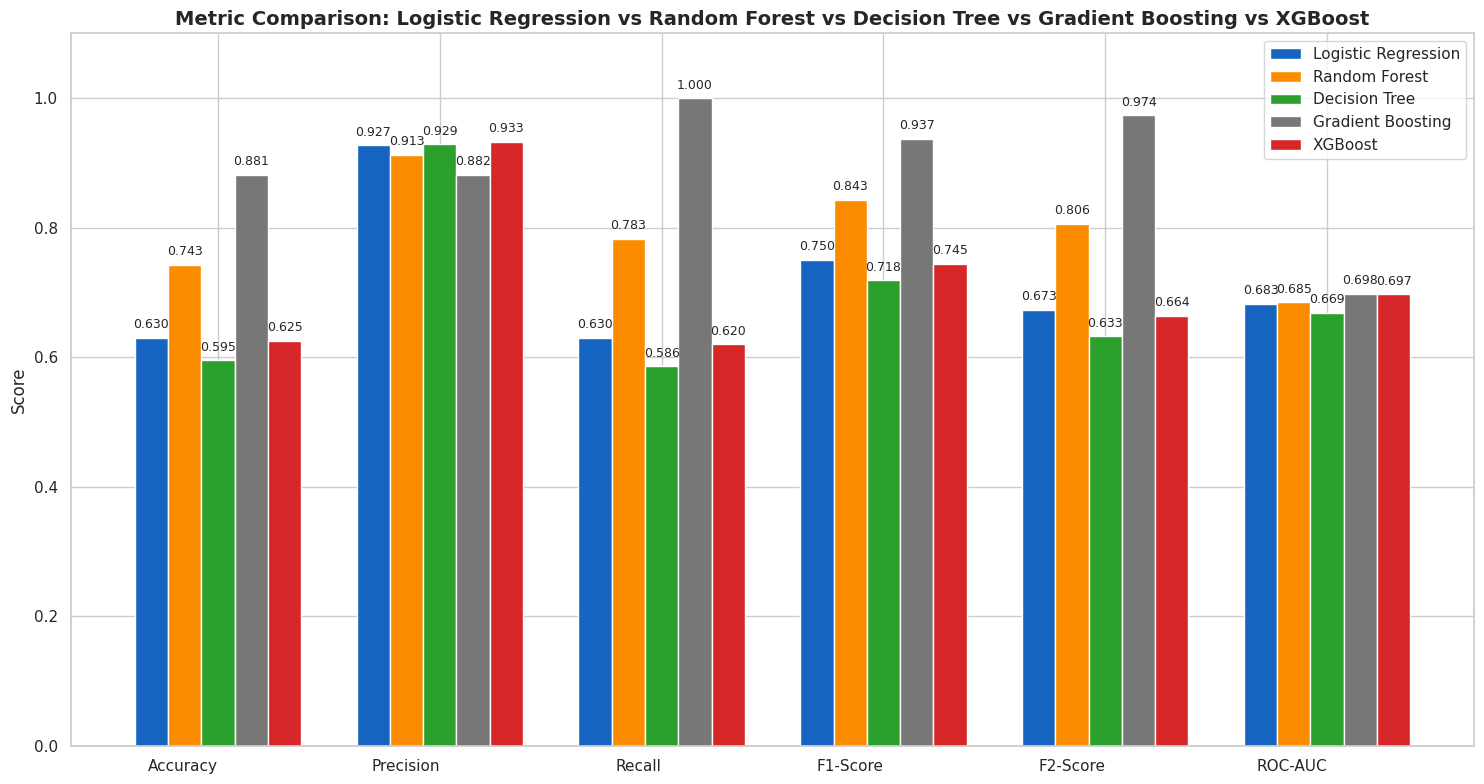

In [98]:
fig, ax = plt.subplots(figsize=(15, 8)) # Increased figure size for better readability
x = np.arange(len(metrics_df.columns))
bar_width = 0.15 # Smaller width for individual bars

# Calculate distinct positions for 5 bars around each x-tick
offset1 = -2 * bar_width
offset2 = -1 * bar_width
offset3 = 0
offset4 = 1 * bar_width
offset5 = 2 * bar_width

bars1 = ax.bar(x + offset1, metrics_df.iloc[0].values, bar_width, label='Logistic Regression',
               color='#1565C0', edgecolor='white')
bars2 = ax.bar(x + offset2, metrics_df.iloc[1].values, bar_width, label='Random Forest',
               color='#FB8C00', edgecolor='white')
bars3 = ax.bar(x + offset3, metrics_df.iloc[2].values, bar_width, label='Decision Tree',
               color='#2CA02C', edgecolor='white')
bars4 = ax.bar(x + offset4, metrics_df.iloc[3].values, bar_width, label='Gradient Boosting',
               color='#777777', edgecolor='white')
bars5 = ax.bar(x + offset5, metrics_df.iloc[4].values, bar_width, label='XGBoost',
               color='#D62728', edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Metric Comparison: Logistic Regression vs Random Forest vs Decision Tree vs Gradient Boosting vs XGBoost', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.columns, rotation=0, ha='right') # Rotate labels for readability
ax.legend()
ax.set_ylim(0, 1.1)
for b in [bars1, bars2, bars3, bars4, bars5]:
    for bar in b:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import pandas as pd

# Menyiapkan dictionary untuk semua model yang telah dilatih
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model
}

# Fungsi untuk menghitung metrik khusus untuk mendeteksi Bad Loan (kelas 0)
def evaluate_risk_metrics(model, X, y):
    y_pred = model.predict(X)
    # Gunakan pos_label=0 karena kita fokus pada performa memprediksi Bad Loan
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, pos_label=0)
    rec = recall_score(y, y_pred, pos_label=0)
    f1 = f1_score(y, y_pred, pos_label=0)
    f2 = fbeta_score(y, y_pred, beta=2, pos_label=0) # F2-Score memprioritaskan Recall
    return [acc, prec, rec, f1, f2]

# Mengumpulkan hasil
results = []
for name, model in models.items():
    # Metrik Data Training
    train_metrics = evaluate_risk_metrics(model, X_train, y_train)
    # Metrik Data Testing
    test_metrics = evaluate_risk_metrics(model, X_test, y_test)

    results.append([name, 'Train'] + train_metrics)
    results.append([name, 'Test'] + test_metrics)

# Membuat DataFrame Hasil
kolom = ['Model', 'Dataset', 'Accuracy', 'Precision (Bad Loan)', 'Recall (Bad Loan)', 'F1-Score', 'F2-Score']
df_evaluation = pd.DataFrame(results, columns=kolom)

print("=== Ringkasan Evaluasi Model (Fokus pada Deteksi Bad Loan) ===")
display(df_evaluation.pivot(index='Model', columns='Dataset', values=['Recall (Bad Loan)', 'F2-Score', 'Accuracy']))

=== Ringkasan Evaluasi Model (Fokus pada Deteksi Bad Loan) ===


Recall (Bad Loan)            F2-Score            Accuracy  \
Dataset                          Test     Train      Test     Train      Test   
Model                                                                           
Decision Tree                0.666637  0.713934  0.430487  0.460521  0.595419   
Gradient Boosting            0.002169  0.004383  0.002708  0.005471  0.881371   
Logistic Regression          0.633382  0.633556  0.428979  0.428154  0.630290   
Random Forest                0.443069  0.780599  0.365972  0.631968  0.742840   
XGBoost                      0.666998  0.686147  0.445153  0.456751  0.625294   

                               
Dataset                 Train  
Model                          
Decision Tree        0.605611  
Gradient Boosting    0.881781  
Logistic Regression  0.628384  
Random Forest        0.808384  
XGBoost              0.627519

### Confusion Matrix

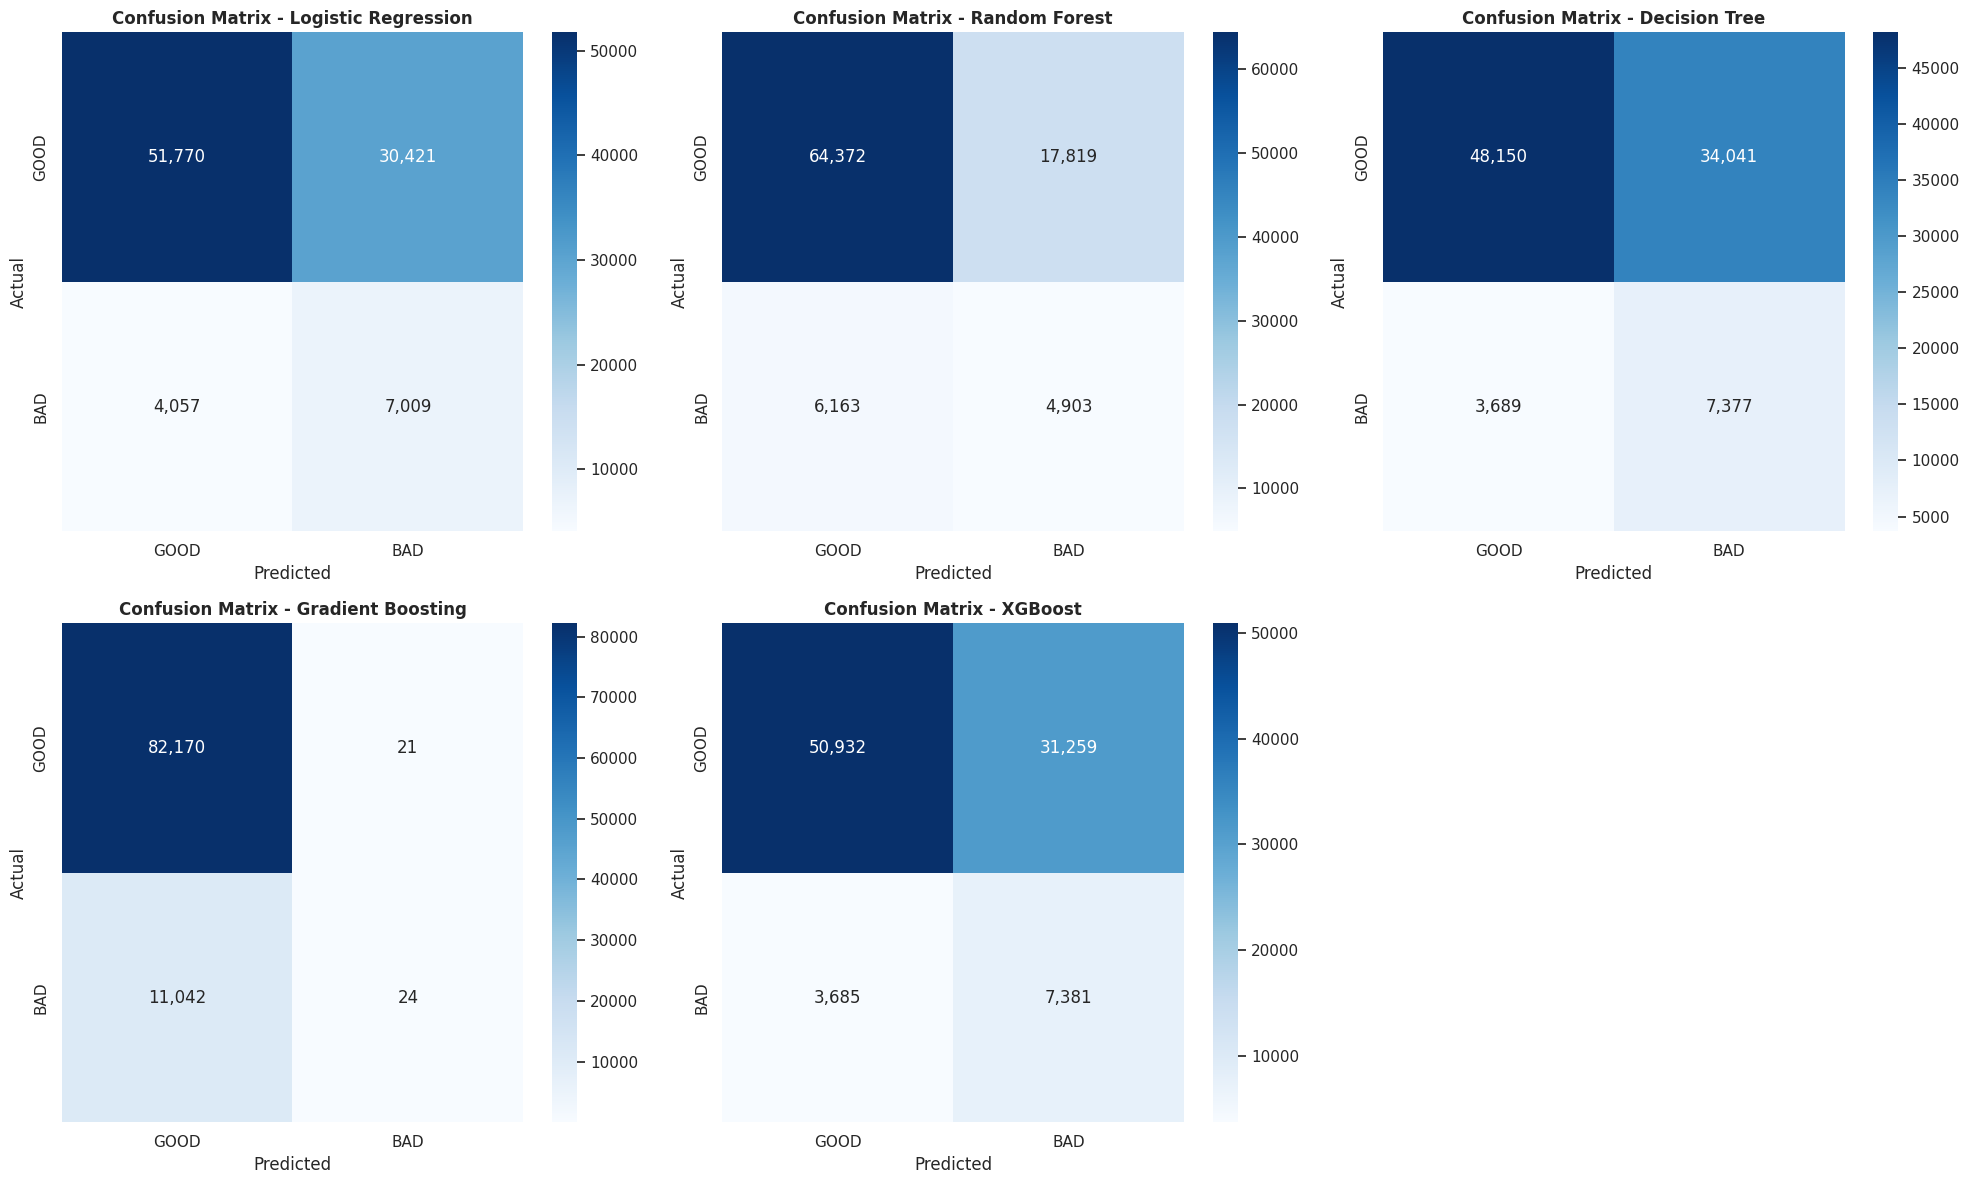

In [93]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate([('Logistic Regression', y_pred_lr),
                                    ('Random Forest', y_pred_rf),
                                    ('Decision Tree',y_pred_dt),
                                    ('Gradient Boosting', y_pred_gb),
                                    ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[i],
                xticklabels=['GOOD', 'BAD'], yticklabels=['GOOD', 'BAD'])
    axes[i].set_title(f'Confusion Matrix - {name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Dalam konteks credit risk, XGBoost adalah pilihan terbaik karena paling efektif menangkap bad loan — meskipun bukan yang “paling akurat” secara total.

### Visualisasi Kurva ROC (Receiver Operating Characteristic)

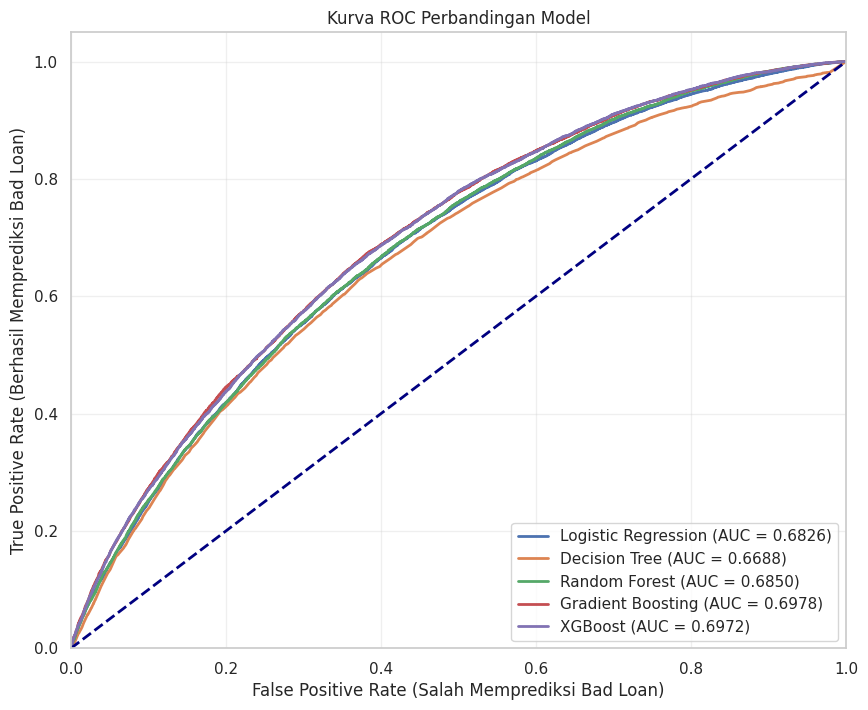

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Mengambil probabilitas prediksi untuk kelas 0 (Bad Loan)
    y_prob_bad_loan = model.predict_proba(X_test)[:, 0]

    # Untuk menghitung ROC kurva memprediksi kelas 0, kita balik label y_test sementara (0 jadi 1, 1 jadi 0)
    y_test_inverted = 1 - y_test

    fpr, tpr, thresholds = roc_curve(y_test_inverted, y_prob_bad_loan)
    auc_score = roc_auc_score(y_test_inverted, y_prob_bad_loan)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

# Garis diagonal (tebakan acak / baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Memprediksi Bad Loan)')
plt.ylabel('True Positive Rate (Berhasil Memprediksi Bad Loan)')
plt.title('Kurva ROC Perbandingan Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Semua model mampu mengurutkan risiko dengan cukup baik (AUC ~0.69), namun hanya XGBoost yang mampu menerjemahkan ranking risiko tersebut menjadi keputusan operasional yang efektif dalam mendeteksi bad loan.

### Feature Importance

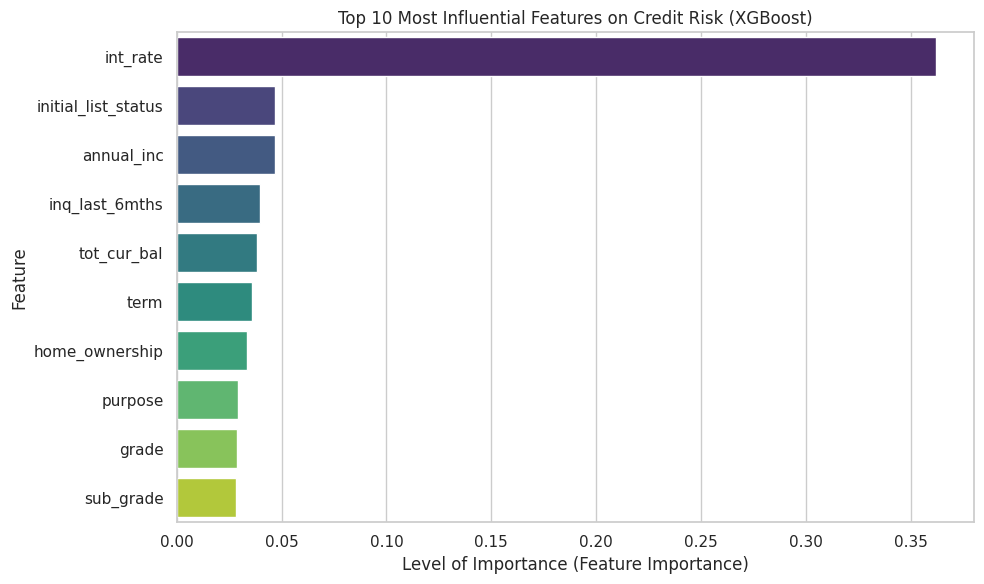

In [97]:
# Kita ambil contoh menggunakan XGBoost model untuk melihat fitur apa yang paling penting
best_model = xgb_model

# Memastikan nama kolom fitur diambil dari X_train sebelum di-scaling
# Pastikan X_train adalah dataframe. Jika X_train_scaled berupa numpy array, gunakan kolom dari X asli
feature_names = X.columns

importances = best_model.feature_importances_

# Membuat DataFrame Feature Importance
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi 10 Fitur Paling Berpengaruh
plt.figure(figsize=(10, 6))
import seaborn as sns
sns.barplot(x='Importance', y='Feature', data=df_importances.head(10), palette='viridis')
plt.title('Top 10 Most Influential Features on Credit Risk (XGBoost)')
plt.xlabel('Level of Importance (Feature Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

SHAP values berhasil dihitung. Sekarang akan menampilkan visualisasi...


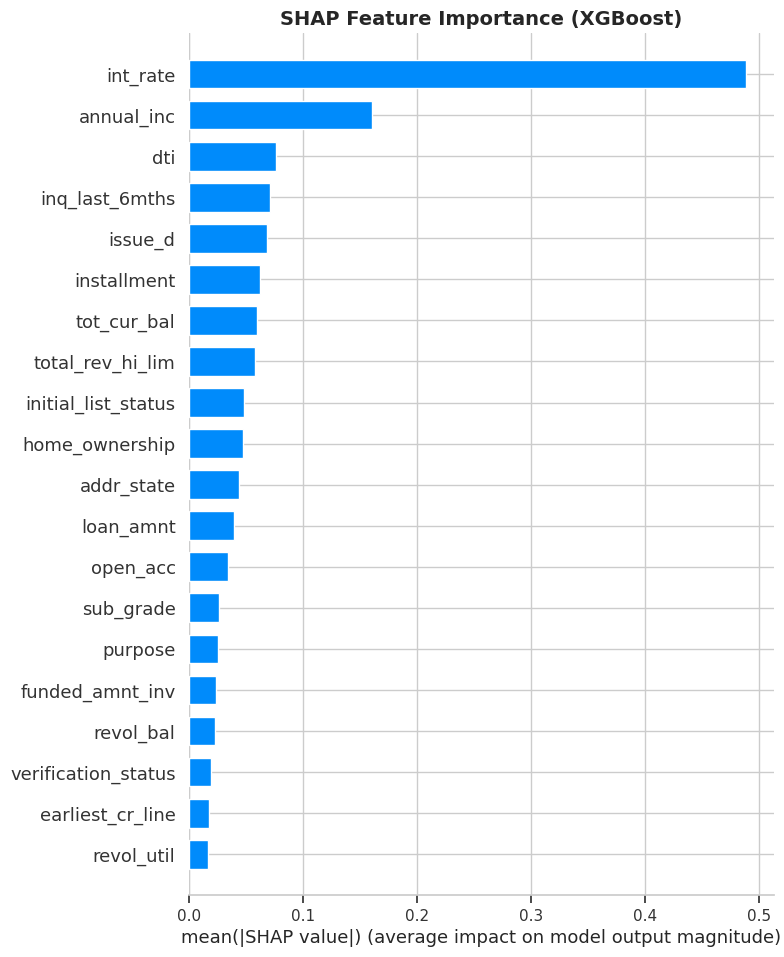

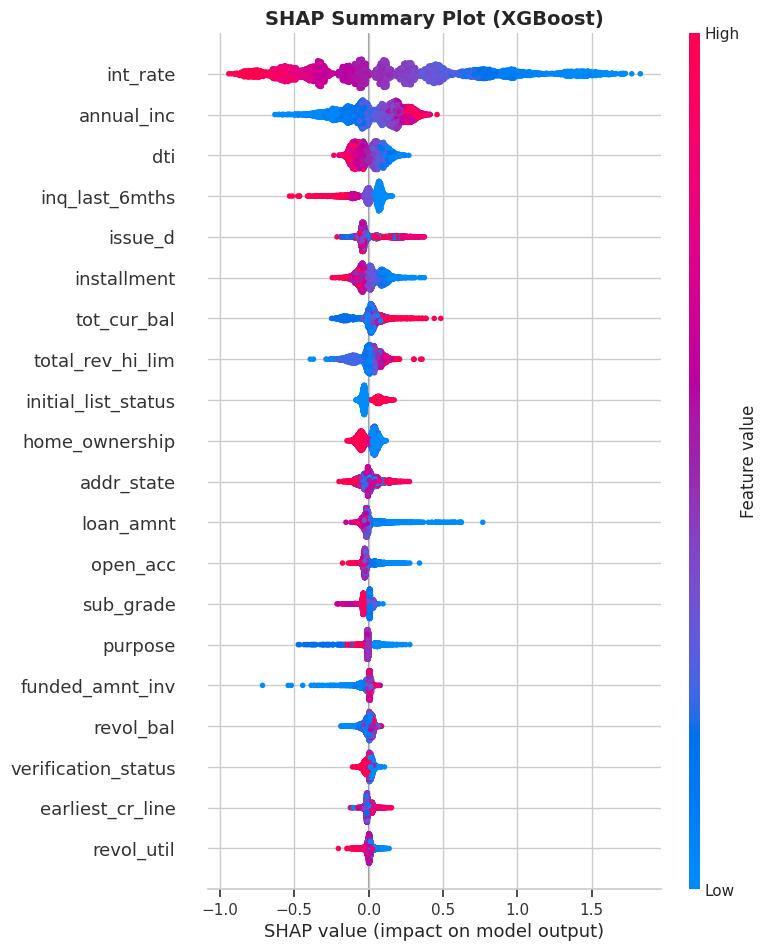

In [96]:
# Import library SHAP
import shap

# Memilih model terbaik (XGBoost) dari tahapan sebelumnya
best_model = xgb_model

# Mengambil sampel data dari X_test untuk perhitungan SHAP agar lebih cepat
# SHAP calculations can be computationally intensive
X_test_sample = X_test.sample(n=5000, random_state=42)

# Membuat SHAP Explainer untuk model berbasis pohon (TreeExplainer)
# Jika X_train terlalu besar, kita bisa menggunakan subset untuk background data
explainer = shap.TreeExplainer(best_model)

# Menghitung SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values berhasil dihitung. Sekarang akan menampilkan visualisasi...")

# Visualisasi SHAP (Summary Plot)
# Ini menunjukkan pentingnya setiap fitur dan dampak positif/negatifnya
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.show()

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot (XGBoost)', fontsize=14, fontweight='bold')
plt.show()

# Optional: Visualisasi SHAP (Force Plot) untuk satu observasi
# Misalnya untuk observasi pertama di sampel
# print("SHAP Force Plot untuk observasi pertama:")
# shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_sample.iloc[0,:])

In [100]:
# To save the entire notebook as a Python (.py) file, please use the Colab menu:
# File > Download > Download .py
